In [1]:
import numpy as np 
import pandas as pd 

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/.DS_Store
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/val/.DS_Store
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA/person1947_bacteria_4876.jpeg
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA/person1946_bacteria_4875.jpeg
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA/person1952_bacteria_4883.jpeg
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA/person1954_bacteria_4886.jpeg
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA/person1951_bacteria_4882.jpeg
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA/person1946_bacteria_4874.jpeg
/kaggle/input/datasets/paultimothymooney

Using device: cuda
Dataset root: /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray

Class mapping: {'NORMAL': 0, 'PNEUMONIA': 1}
Train full shape: (5216, 3)
Test shape: (624, 3)

Split sizes:
Train: 4433
Val  : 783
Test : 624

Train distribution:
label_name
PNEUMONIA    3293
NORMAL       1140
Name: count, dtype: int64

Validation distribution:
label_name
PNEUMONIA    582
NORMAL       201
Name: count, dtype: int64

Test distribution:
label_name
PNEUMONIA    390
NORMAL       234
Name: count, dtype: int64

Class weights: tensor([2., 1.], device='cuda:0')

Model created successfully.
FairAttentionCNN(
  (features): Sequential(
    (0): ConvBlock(
      (block): Sequential(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
      )
      (se): Identity()
      (pool): MaxPool2d(kernel_size=2, stride=2, paddi

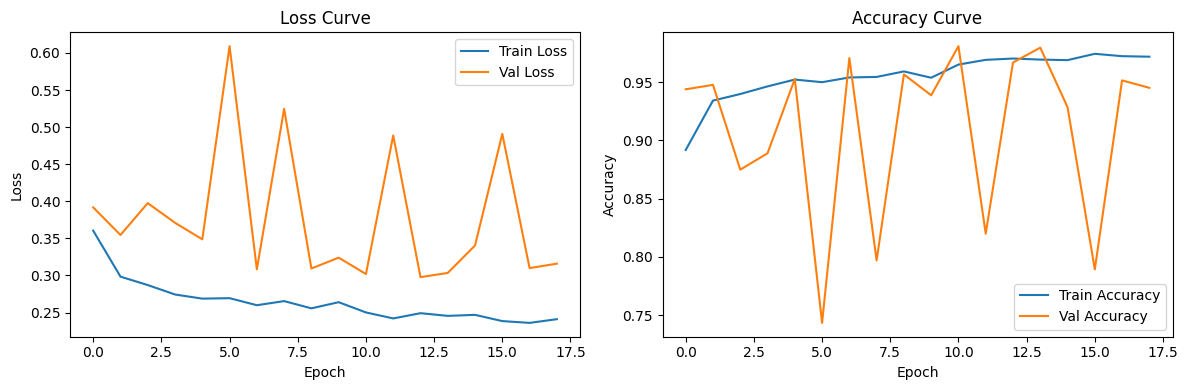


Best threshold from validation set: 0.25
Best validation F1 at tuned threshold: 0.9880

==================== TEST RESULTS (THRESHOLD = 0.50) ====================
Test Loss     : 0.4234
Accuracy      : 0.9022
Precision     : 0.8747
Recall        : 0.9846
F1-Score      : 0.9264
ROC-AUC       : 0.9641
Training Time : 1158.28 sec
Testing Time  : 13.73 sec

Classification Report (0.50):
              precision    recall  f1-score   support

      NORMAL       0.97      0.76      0.85       234
   PNEUMONIA       0.87      0.98      0.93       390

    accuracy                           0.90       624
   macro avg       0.92      0.87      0.89       624
weighted avg       0.91      0.90      0.90       624


Per-class accuracy (0.50):
NORMAL: 0.7650
PNEUMONIA: 0.9846

==================== TEST RESULTS (TUNED THRESHOLD) ====================
Tuned Threshold: 0.25
Test Loss      : 0.4234
Accuracy       : 0.8317
Precision      : 0.7902
Recall         : 0.9949
F1-Score       : 0.8808
ROC-AUC   

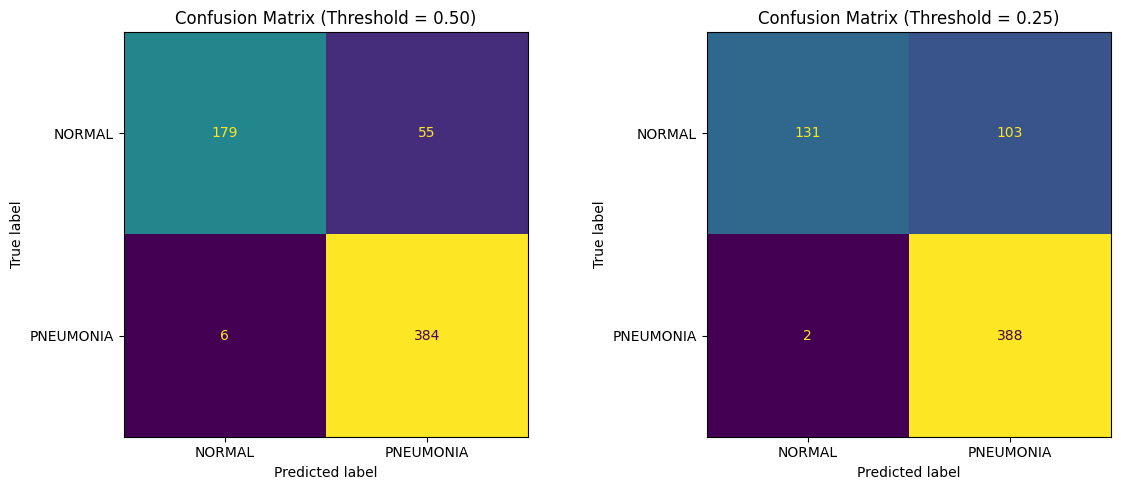

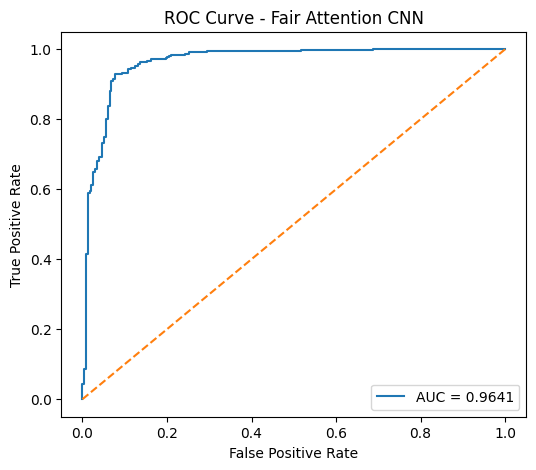


Saved files:
/kaggle/working/fair_attention_cnn_best.pth
/kaggle/working/fair_attention_cnn_results.csv
/kaggle/working/fair_attention_cnn_per_class_accuracy.csv
/kaggle/working/fair_attention_cnn_history.csv

==================== TASK 3 vs TASK 4 ====================
      Metric  Task 3 Custom CNN  Task 4 Attention CNN (0.50)  \
0   Accuracy             0.9006                     0.902244   
1  Precision             0.8727                     0.874715   
2     Recall             0.9846                     0.984615   
3   F1-Score             0.9253                     0.926417   
4    ROC-AUC             0.9550                     0.964059   

   Task 4 Attention CNN (Tuned)  
0                      0.831731  
1                      0.790224  
2                      0.994872  
3                      0.880817  
4                      0.964059  

Saved comparison file:
/kaggle/working/task3_vs_task4_comparison.csv


In [2]:
# ============================================================
# TASK 4: ATTENTION-ENHANCED CNN (SE BLOCK)
# ============================================================

import os
import time
import copy
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms

warnings.filterwarnings("ignore")

# =========================
# 1. Reproducibility
# =========================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# =========================
# 2. Dataset path
# =========================
def find_dataset_root():
    candidates = [
        "/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray",
        "/kaggle/input/chest-xray-pneumonia/chest_xray",
        "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray",
        "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray",
    ]

    for path in candidates:
        train_dir = os.path.join(path, "train")
        test_dir = os.path.join(path, "test")
        if os.path.exists(train_dir) and os.path.exists(test_dir):
            return path

    for root, dirs, files in os.walk("/kaggle/input"):
        if os.path.basename(root) == "chest_xray":
            train_dir = os.path.join(root, "train")
            test_dir = os.path.join(root, "test")
            if os.path.exists(train_dir) and os.path.exists(test_dir):
                return root

    raise FileNotFoundError("Could not find dataset root under /kaggle/input")

DATASET_ROOT = find_dataset_root()
TRAIN_DIR = os.path.join(DATASET_ROOT, "train")
TEST_DIR = os.path.join(DATASET_ROOT, "test")
IMG_EXTENSIONS = (".jpg", ".jpeg", ".png")

print("Dataset root:", DATASET_ROOT)

# =========================
# 3. Load file paths
# =========================
def collect_image_paths_and_labels(root_dir):
    data = []
    classes = sorted([d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))])
    class_to_idx = {cls_name: idx for idx, cls_name in enumerate(classes)}

    for cls_name in classes:
        cls_path = os.path.join(root_dir, cls_name)
        for file_name in os.listdir(cls_path):
            if file_name.lower().endswith(IMG_EXTENSIONS):
                file_path = os.path.join(cls_path, file_name)
                data.append([file_path, cls_name, class_to_idx[cls_name]])

    df = pd.DataFrame(data, columns=["file_path", "label_name", "label"])
    return df, class_to_idx

train_df_full, class_to_idx = collect_image_paths_and_labels(TRAIN_DIR)
test_df, _ = collect_image_paths_and_labels(TEST_DIR)

idx_to_class = {v: k for k, v in class_to_idx.items()}
num_classes = len(class_to_idx)

print("\nClass mapping:", class_to_idx)
print("Train full shape:", train_df_full.shape)
print("Test shape:", test_df.shape)

# =========================
# 4. Train-validation split
# =========================
train_df, val_df = train_test_split(
    train_df_full,
    test_size=0.15,
    stratify=train_df_full["label"],
    random_state=SEED
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("\nSplit sizes:")
print("Train:", len(train_df))
print("Val  :", len(val_df))
print("Test :", len(test_df))

# =========================
# 5. Show class distribution
# =========================
def show_distribution(df, name):
    counts = df["label_name"].value_counts()
    print(f"\n{name} distribution:")
    print(counts)
    return counts

train_counts = show_distribution(train_df, "Train")
val_counts = show_distribution(val_df, "Validation")
test_counts = show_distribution(test_df, "Test")

# =========================
# 6. Transforms
# Same as Task 3
# =========================
IMG_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.90, 1.00)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(8),
    transforms.ColorJitter(brightness=0.10, contrast=0.10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.485, 0.485], std=[0.229, 0.229, 0.229])
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.485, 0.485], std=[0.229, 0.229, 0.229])
])

# =========================
# 7. Custom dataset
# =========================
class ChestXrayDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        image = Image.open(row["file_path"]).convert("L").convert("RGB")
        label = int(row["label"])

        if self.transform:
            image = self.transform(image)

        return image, label

train_dataset = ChestXrayDataset(train_df, transform=train_transform)
val_dataset = ChestXrayDataset(val_df, transform=eval_transform)
test_dataset = ChestXrayDataset(test_df, transform=eval_transform)

# =========================
# 8. Handle imbalance
# Same as Task 3
# =========================
class_weights = torch.tensor([2.0, 1.0], dtype=torch.float).to(device)
print("\nClass weights:", class_weights)

train_label_counts = train_df["label"].value_counts().sort_index().to_dict()
sample_weights = train_df["label"].map(lambda x: 1.0 / train_label_counts[x]).values
sample_weights = torch.DoubleTensor(sample_weights)

weighted_sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

# =========================
# 9. Dataloaders
# =========================
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=weighted_sampler,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

# =========================
# 10. SE Attention Block
# =========================
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super(SEBlock, self).__init__()
        reduced_channels = max(channels // reduction, 8)

        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, reduced_channels),
            nn.ReLU(inplace=True),
            nn.Linear(reduced_channels, channels),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y

# =========================
# 11. Conv Block
# =========================
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, use_se=False):
        super(ConvBlock, self).__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
        self.use_se = use_se
        self.se = SEBlock(out_channels) if use_se else nn.Identity()
        self.pool = nn.MaxPool2d(2)

    def forward(self, x):
        x = self.block(x)
        x = self.se(x)
        x = self.pool(x)
        return x

# =========================
# 12. Attention-Enhanced CNN
# =========================
class FairAttentionCNN(nn.Module):
    def __init__(self, num_classes=2):
        super(FairAttentionCNN, self).__init__()

        self.features = nn.Sequential(
            ConvBlock(3, 32, use_se=False),
            ConvBlock(32, 64, use_se=False),
            ConvBlock(64, 128, use_se=False),
            ConvBlock(128, 256, use_se=True),   # deep block 1 with SE
            ConvBlock(256, 256, use_se=True)    # deep block 2 with SE
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(128),
            nn.Dropout(0.4),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = FairAttentionCNN(num_classes=num_classes).to(device)
print("\nModel created successfully.")
print(model)

# =========================
# 13. Loss, optimizer, scheduler
# =========================
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
optimizer = optim.Adam(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    patience=2,
    factor=0.5
)

# =========================
# 14. Training and evaluation functions
# =========================
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)

    return epoch_loss, epoch_acc

def evaluate(model, loader, criterion, threshold=0.5):
    model.eval()
    running_loss = 0.0
    all_probs = []
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)
            loss = criterion(outputs, labels)

            probs = torch.softmax(outputs, dim=1)[:, 1]
            preds = (probs >= threshold).long()

            running_loss += loss.item() * images.size(0)
            all_probs.extend(probs.detach().cpu().numpy())
            all_preds.extend(preds.detach().cpu().numpy())
            all_labels.extend(labels.detach().cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)

    return epoch_loss, epoch_acc, np.array(all_labels), np.array(all_preds), np.array(all_probs)

def find_best_threshold(y_true, y_prob):
    thresholds = np.arange(0.10, 0.91, 0.05)
    best_threshold = 0.50
    best_f1 = -1.0

    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        score = f1_score(y_true, y_pred, average="binary", zero_division=0)
        if score > best_f1:
            best_f1 = score
            best_threshold = t

    return best_threshold, best_f1

def compute_metrics(y_true, y_pred, y_prob):
    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average="binary", zero_division=0)
    recall = recall_score(y_true, y_pred, average="binary", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="binary", zero_division=0)
    auc = roc_auc_score(y_true, y_prob)

    cm = confusion_matrix(y_true, y_pred)
    class_acc = cm.diagonal() / cm.sum(axis=1)

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "auc": auc,
        "cm": cm,
        "class_acc": class_acc
    }

# =========================
# 15. Training loop with early stopping
# =========================
EPOCHS = 20
PATIENCE = 5

best_val_loss = float("inf")
best_model_wts = copy.deepcopy(model.state_dict())
best_epoch = 0
early_stop_counter = 0

history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": []
}

start_train_time = time.time()

for epoch in range(EPOCHS):
    epoch_start = time.time()

    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc, _, _, _ = evaluate(model, val_loader, criterion, threshold=0.5)

    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | "
        f"Time: {time.time() - epoch_start:.1f}s"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch + 1
        best_model_wts = copy.deepcopy(model.state_dict())
        early_stop_counter = 0
        torch.save(model.state_dict(), "/kaggle/working/fair_attention_cnn_best.pth")
    else:
        early_stop_counter += 1
        if early_stop_counter >= PATIENCE:
            print("\nEarly stopping triggered.")
            break

total_train_time = time.time() - start_train_time
print(f"\nBest epoch: {best_epoch}")
print(f"Total training time: {total_train_time:.2f} seconds")

model.load_state_dict(best_model_wts)

# =========================
# 16. Plot history
# =========================
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history["train_acc"], label="Train Accuracy")
plt.plot(history["val_acc"], label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")
plt.legend()

plt.tight_layout()
plt.show()

# =========================
# 17. Validation threshold tuning
# Use validation set only
# =========================
val_loss, val_acc, val_y_true, val_y_pred_05, val_y_prob = evaluate(
    model, val_loader, criterion, threshold=0.5
)

best_threshold, best_val_f1 = find_best_threshold(val_y_true, val_y_prob)

print(f"\nBest threshold from validation set: {best_threshold:.2f}")
print(f"Best validation F1 at tuned threshold: {best_val_f1:.4f}")

# =========================
# 18. Final test evaluation
# Report both threshold=0.50 and tuned threshold
# =========================
start_test_time = time.time()

# Threshold 0.50
test_loss_05, test_acc_05, y_true_05, y_pred_05, y_prob_05 = evaluate(
    model, test_loader, criterion, threshold=0.50
)

# Tuned threshold
test_loss_tuned, test_acc_tuned, y_true_tuned, y_pred_tuned, y_prob_tuned = evaluate(
    model, test_loader, criterion, threshold=best_threshold
)

test_time = time.time() - start_test_time

metrics_05 = compute_metrics(y_true_05, y_pred_05, y_prob_05)
metrics_tuned = compute_metrics(y_true_tuned, y_pred_tuned, y_prob_tuned)

print("\n==================== TEST RESULTS (THRESHOLD = 0.50) ====================")
print(f"Test Loss     : {test_loss_05:.4f}")
print(f"Accuracy      : {metrics_05['accuracy']:.4f}")
print(f"Precision     : {metrics_05['precision']:.4f}")
print(f"Recall        : {metrics_05['recall']:.4f}")
print(f"F1-Score      : {metrics_05['f1']:.4f}")
print(f"ROC-AUC       : {metrics_05['auc']:.4f}")
print(f"Training Time : {total_train_time:.2f} sec")
print(f"Testing Time  : {test_time:.2f} sec")

print("\nClassification Report (0.50):")
print(classification_report(y_true_05, y_pred_05, target_names=[idx_to_class[0], idx_to_class[1]], zero_division=0))

print("\nPer-class accuracy (0.50):")
for i, acc in enumerate(metrics_05["class_acc"]):
    print(f"{idx_to_class[i]}: {acc:.4f}")

print("\n==================== TEST RESULTS (TUNED THRESHOLD) ====================")
print(f"Tuned Threshold: {best_threshold:.2f}")
print(f"Test Loss      : {test_loss_tuned:.4f}")
print(f"Accuracy       : {metrics_tuned['accuracy']:.4f}")
print(f"Precision      : {metrics_tuned['precision']:.4f}")
print(f"Recall         : {metrics_tuned['recall']:.4f}")
print(f"F1-Score       : {metrics_tuned['f1']:.4f}")
print(f"ROC-AUC        : {metrics_tuned['auc']:.4f}")
print(f"Training Time  : {total_train_time:.2f} sec")
print(f"Testing Time   : {test_time:.2f} sec")

print("\nClassification Report (Tuned):")
print(classification_report(y_true_tuned, y_pred_tuned, target_names=[idx_to_class[0], idx_to_class[1]], zero_division=0))

print("\nPer-class accuracy (Tuned):")
for i, acc in enumerate(metrics_tuned["class_acc"]):
    print(f"{idx_to_class[i]}: {acc:.4f}")

# =========================
# 19. Confusion matrices
# =========================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(metrics_05["cm"], display_labels=[idx_to_class[0], idx_to_class[1]]).plot(
    ax=axes[0], values_format='d', colorbar=False
)
axes[0].set_title("Confusion Matrix (Threshold = 0.50)")

ConfusionMatrixDisplay(metrics_tuned["cm"], display_labels=[idx_to_class[0], idx_to_class[1]]).plot(
    ax=axes[1], values_format='d', colorbar=False
)
axes[1].set_title(f"Confusion Matrix (Threshold = {best_threshold:.2f})")

plt.tight_layout()
plt.show()

# =========================
# 20. ROC curve
# =========================
fpr, tpr, thresholds = roc_curve(y_true_05, y_prob_05)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {metrics_05['auc']:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Fair Attention CNN")
plt.legend(loc="lower right")
plt.show()

# =========================
# 21. Save results
# =========================
results_df = pd.DataFrame({
    "Metric": [
        "Test Loss (0.50)",
        "Accuracy (0.50)",
        "Precision (0.50)",
        "Recall (0.50)",
        "F1-Score (0.50)",
        "ROC-AUC (0.50)",
        "Test Loss (Tuned)",
        "Accuracy (Tuned)",
        "Precision (Tuned)",
        "Recall (Tuned)",
        "F1-Score (Tuned)",
        "ROC-AUC (Tuned)",
        "Best Threshold",
        "Training Time (s)",
        "Testing Time (s)"
    ],
    "Value": [
        test_loss_05,
        metrics_05["accuracy"],
        metrics_05["precision"],
        metrics_05["recall"],
        metrics_05["f1"],
        metrics_05["auc"],
        test_loss_tuned,
        metrics_tuned["accuracy"],
        metrics_tuned["precision"],
        metrics_tuned["recall"],
        metrics_tuned["f1"],
        metrics_tuned["auc"],
        best_threshold,
        total_train_time,
        test_time
    ]
})

per_class_df = pd.DataFrame({
    "Class": [idx_to_class[0], idx_to_class[1]],
    "Class Accuracy (0.50)": metrics_05["class_acc"],
    "Class Accuracy (Tuned)": metrics_tuned["class_acc"]
})

results_df.to_csv("/kaggle/working/fair_attention_cnn_results.csv", index=False)
per_class_df.to_csv("/kaggle/working/fair_attention_cnn_per_class_accuracy.csv", index=False)
pd.DataFrame(history).to_csv("/kaggle/working/fair_attention_cnn_history.csv", index=False)

print("\nSaved files:")
print("/kaggle/working/fair_attention_cnn_best.pth")
print("/kaggle/working/fair_attention_cnn_results.csv")
print("/kaggle/working/fair_attention_cnn_per_class_accuracy.csv")
print("/kaggle/working/fair_attention_cnn_history.csv")

# =========================
# 22. Optional comparison with Task 3
# =========================
task3_metrics = {
    "Accuracy": 0.9006,
    "Precision": 0.8727,
    "Recall": 0.9846,
    "F1-Score": 0.9253,
    "ROC-AUC": 0.9550
}

task4_metrics = {
    "Accuracy (0.50)": metrics_05["accuracy"],
    "Precision (0.50)": metrics_05["precision"],
    "Recall (0.50)": metrics_05["recall"],
    "F1-Score (0.50)": metrics_05["f1"],
    "ROC-AUC (0.50)": metrics_05["auc"],
    "Accuracy (Tuned)": metrics_tuned["accuracy"],
    "Precision (Tuned)": metrics_tuned["precision"],
    "Recall (Tuned)": metrics_tuned["recall"],
    "F1-Score (Tuned)": metrics_tuned["f1"],
    "ROC-AUC (Tuned)": metrics_tuned["auc"],
}

comparison_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],
    "Task 3 Custom CNN": [
        task3_metrics["Accuracy"],
        task3_metrics["Precision"],
        task3_metrics["Recall"],
        task3_metrics["F1-Score"],
        task3_metrics["ROC-AUC"]
    ],
    "Task 4 Attention CNN (0.50)": [
        task4_metrics["Accuracy (0.50)"],
        task4_metrics["Precision (0.50)"],
        task4_metrics["Recall (0.50)"],
        task4_metrics["F1-Score (0.50)"],
        task4_metrics["ROC-AUC (0.50)"]
    ],
    "Task 4 Attention CNN (Tuned)": [
        task4_metrics["Accuracy (Tuned)"],
        task4_metrics["Precision (Tuned)"],
        task4_metrics["Recall (Tuned)"],
        task4_metrics["F1-Score (Tuned)"],
        task4_metrics["ROC-AUC (Tuned)"]
    ]
})

print("\n==================== TASK 3 vs TASK 4 ====================")
print(comparison_df)

comparison_df.to_csv("/kaggle/working/task3_vs_task4_comparison.csv", index=False)
print("\nSaved comparison file:")
print("/kaggle/working/task3_vs_task4_comparison.csv")